In [1]:
!pip install pandas==2.2.3 numpy==2.1.3 seaborn==0.13.2 matplotlib==3.10.0 scikit-learn xgboost

1.Load Datasets

In [1]:
# Import required libraries
import pandas as pd       # version: 2.2.3
import numpy as np        # version: 2.1.3
import seaborn as sns     # version: 0.13.2
import matplotlib.pyplot as plt  # version: 3.10.0
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Display a list of all files and folders
import os
print("Current folder:")
print(os.getcwd())
print("\nFiles and folders:")
print(os.listdir())

Current folder:
C:\Users\acer\OneDrive - AHEAD - Amrita Vishwa Vidyapeetham\Desktop\sales forecasting files

Files and folders:
['.ipynb_checkpoints', 'additional_visualizations.py', 'app.py', 'bigmart_model.pkl', 'datasets', 'model', 'models', 'Retail_Sales_Forecasting.ipynb', 'Sales_Forecasting (2).ipynb', 'SALES_FORECASTING.ipynb', 'time_series.py', 'Untitled.ipynb', 'utils.py', 'utils_report.py', 'visualizations.py', '__pycache__']


In [3]:
# Load training dataset
data = pd.read_csv('datasets/train.csv')

In [4]:
# Preview dataset
data.sample(10).style.set_caption("Sample Preview of the Dataset").set_table_attributes('style="width:100%"')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
4248,FDI33,nan,Low Fat,0.028281,Snack Foods,90.214600,OUT027,1985,Medium,Tier 3,Supermarket Type3,3648.584000
7625,FDZ14,7.710000,Regular,0.047589,Dairy,122.475600,OUT046,1997,Small,Tier 1,Supermarket Type1,605.878000
5052,NCX18,14.150000,Low Fat,0.000000,Household,196.311000,OUT046,1997,Small,Tier 1,Supermarket Type1,3338.987000
1044,FDO09,13.500000,Regular,0.125529,Snack Foods,262.191000,OUT045,2002,nan,Tier 2,Supermarket Type1,6048.793000
5488,FDX11,16.000000,Regular,0.106752,Baking Goods,181.463400,OUT046,1997,Small,Tier 1,Supermarket Type1,1090.580400
7057,FDP59,nan,Regular,0.056192,Breads,103.164800,OUT027,1985,Medium,Tier 3,Supermarket Type3,1973.431200
4113,NCY17,18.200000,Low Fat,0.000000,Health and Hygiene,44.108600,OUT045,2002,nan,Tier 2,Supermarket Type1,1115.215000
5894,FDH31,nan,Regular,0.000000,Meat,98.204200,OUT019,1985,Small,Tier 1,Grocery Store,198.408400
4463,FDI04,13.650000,reg,0.073060,Frozen Foods,196.242600,OUT045,2002,nan,Tier 2,Supermarket Type1,2570.653800
7032,FDS15,9.195000,Regular,0.130657,Meat,106.459600,OUT010,1998,nan,Tier 3,Grocery Store,215.719200


In [5]:
# Dataset shape
print("Shape of dataset:", data.shape)

Shape of dataset: (8523, 12)


In [6]:
# Summary statistics
data.describe().style.set_caption(" Summary Statistics of Numerical Columns").set_table_attributes("style='width:100%'")

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [7]:
# Null value count
print("Null values: ", data.isnull().sum())

Null values:  Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [8]:
# Null value percentage
missing_percentage = data.isnull().sum() * 100 / len(data)
print(missing_percentage)

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64


In [9]:
# Check for duplicates
print("Duplicates: ", data.duplicated().any())

Duplicates:  False


2.Exploratory Data Analysis (EDA)

In [10]:
# Handle missing values in Item_Weight
mean_weight = data['Item_Weight'].mean()
median_weight = data['Item_Weight'].median()
data['Item_Weight_mean'] = data['Item_Weight'].fillna(mean_weight)
data['Item_Weight_median'] = data['Item_Weight'].fillna(median_weight)
data['Item_Weight_interploate'] = data['Item_Weight'].interpolate(method="linear")

In [11]:
# KNN Imputer
from sklearn.impute import KNNImputer
knn = KNNImputer(n_neighbors=10, weights="distance")
data['knn_imputer'] = knn.fit_transform(data[['Item_Weight']]).ravel()

In [12]:
# Drop imputation helper columns
data = data.drop(['Item_Weight', 'Item_Weight_mean', 'Item_Weight_median', 'knn_imputer'], axis=1)

In [13]:
# Handle Outlet_Size using mode of Outlet_Type
mode_outlet = data.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=lambda x: x.mode()[0])
data.loc[data['Outlet_Size'].isnull(), 'Outlet_Size'] = data.loc[data['Outlet_Size'].isnull(), 'Outlet_Type'].apply(lambda x: mode_outlet[x])

In [14]:
# Standardize Fat Content
data.replace({'Item_Fat_Content': {'Low Fat': 'LF', 'low fat': 'LF', 'reg': 'Regular'}}, inplace=True)

In [15]:
# Handle Item_Visibility
data['Item_Visibility_interpolate'] = data['Item_Visibility'].replace(0, np.nan).interpolate(method='linear')
data = data.drop('Item_Visibility', axis=1)

In [16]:
# Simplify Item_Identifier
data['Item_Identifier'] = data['Item_Identifier'].apply(lambda x: x[:2])

In [17]:
# Create Outlet Age
import datetime as dt
current_year = dt.datetime.today().year
data['Outlet_age'] = current_year - data['Outlet_Establishment_Year']
data = data.drop('Outlet_Establishment_Year', axis=1)

In [18]:
# Ordinal Encoding for categorical columns
from sklearn.preprocessing import OrdinalEncoder
data_encoded = data.copy()
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    oe = OrdinalEncoder()
    data_encoded[col] = oe.fit_transform(data_encoded[[col]])

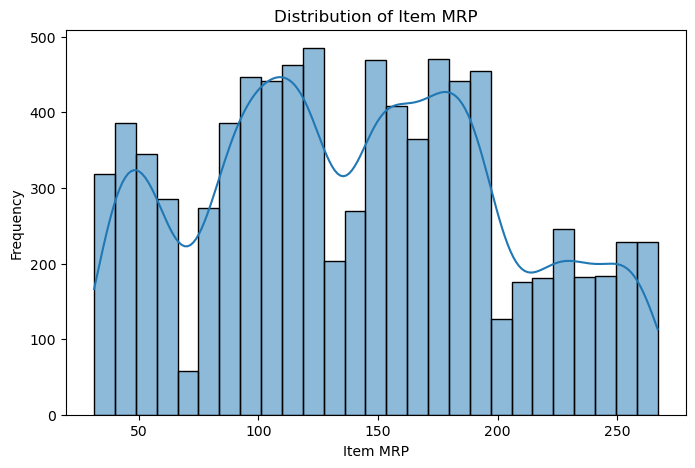

In [19]:
# Distribution of Item MRP
plt.figure(figsize=(8, 5))
sns.histplot(data['Item_MRP'], kde=True)
plt.title('Distribution of Item MRP')
plt.xlabel('Item MRP')
plt.ylabel('Frequency')
plt.show()

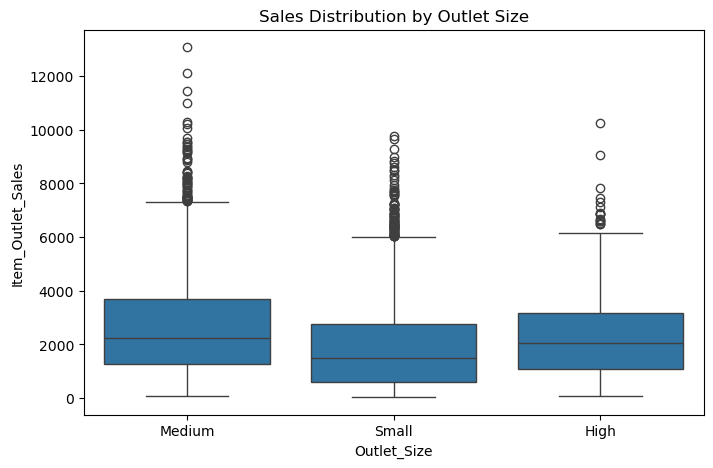

In [20]:
# Boxplot: Sales vs Outlet Size
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=data)
plt.title('Sales Distribution by Outlet Size')
plt.show()

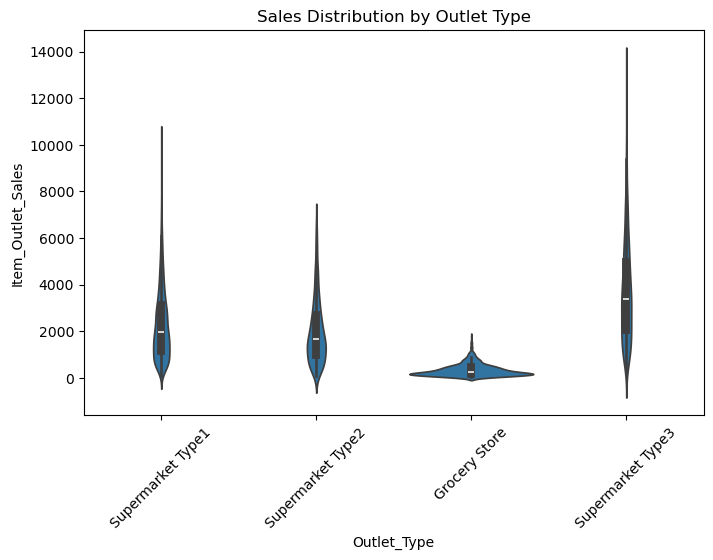

In [21]:
# Violinplot: Sales vs Outlet Type
plt.figure(figsize=(8, 5))
sns.violinplot(x='Outlet_Type', y='Item_Outlet_Sales', data=data)
plt.title('Sales Distribution by Outlet Type')
plt.xticks(rotation=45)
plt.show()

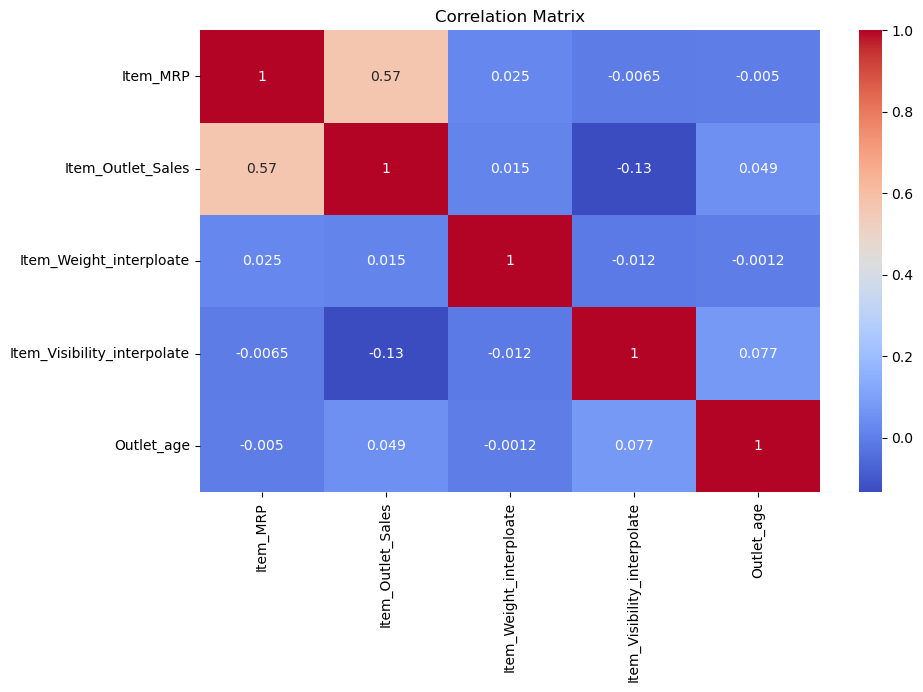

In [22]:
# Correlation Matrix
plt.figure(figsize=(10, 6))
corr = data.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

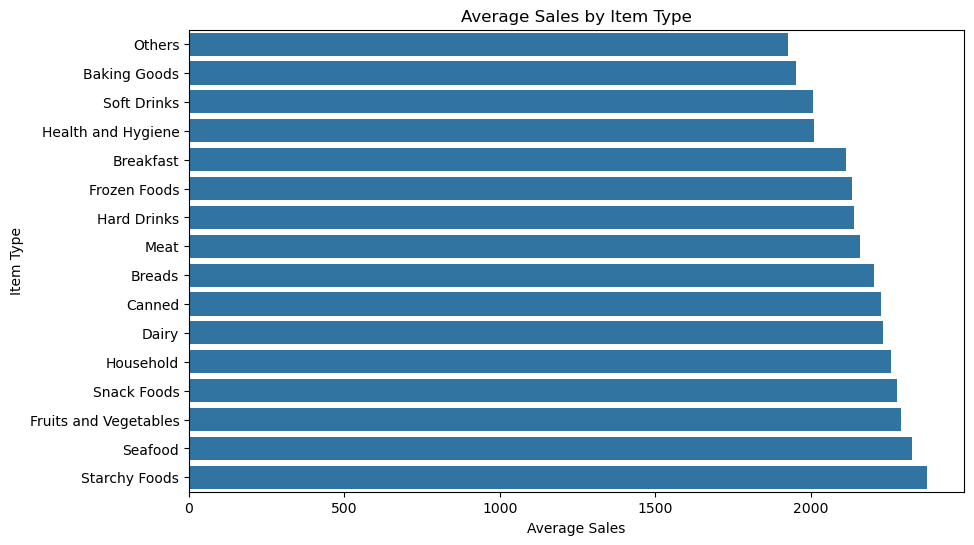

In [23]:
# Barplot: Average Sales by Item Type
item_sales = data.groupby('Item_Type')['Item_Outlet_Sales'].mean().sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=item_sales.values, y=item_sales.index)
plt.title('Average Sales by Item Type')
plt.xlabel('Average Sales')
plt.ylabel('Item Type')
plt.show()

3.Check for Best ML Model

In [25]:
# Step 3: Model Selection and Comparison
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRFRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

In [26]:
# Define features and target
X = data_encoded.drop('Item_Outlet_Sales', axis=1)
y = data_encoded['Item_Outlet_Sales']

In [27]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBRF Regressor": XGBRFRegressor(n_estimators=100, random_state=42)
}

In [28]:
# Store results
model_scores = {}

In [29]:
# Evaluate each model using 5-fold cross-validation (R² score)
for name, model in models.items():
    score = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    model_scores[name] = score
    print(f"{name} R2 Score: {score:.4f}")

Linear Regression R2 Score: 0.5015
Ridge Regression R2 Score: 0.5015
Lasso Regression R2 Score: 0.5015
Decision Tree R2 Score: 0.1578
Random Forest R2 Score: 0.5550
XGBRF Regressor R2 Score: 0.5956


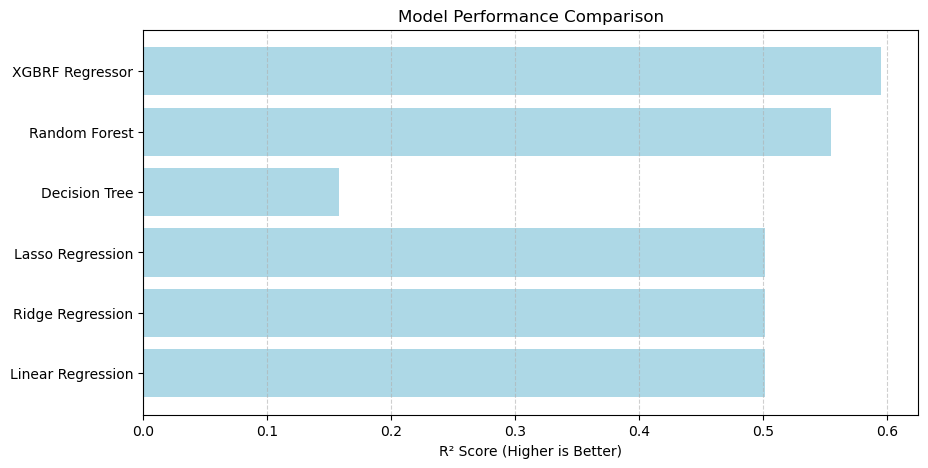

In [30]:
# Bar plot of model R² scores
plt.figure(figsize=(10, 5))
plt.barh(list(model_scores.keys()), list(model_scores.values()), color='lightblue')
plt.xlabel("R² Score (Higher is Better)")
plt.title("Model Performance Comparison")
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.show()

In [31]:
# Train multiple machine learning models and evaluate their performance using Mean Absolute Error (MAE)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} MAE: {mae:.2f}")

Linear Regression MAE: 855.57
Ridge Regression MAE: 855.35
Lasso Regression MAE: 855.57
Decision Tree MAE: 1017.66
Random Forest MAE: 757.32
XGBRF Regressor MAE: 715.47


4.Train Final Model

In [32]:
# Train XGBRF model to get feature importances
xg1 = XGBRFRegressor(n_estimators=100, random_state=42)
xg1.fit(X, y)

# Manually selected low-importance features based on feature importance analysis
important_cols = ['Item_Visibility_interpolate', 'Item_Weight_interploate', 'Item_Type',
                  'Outlet_Location_Type', 'Item_Identifier', 'Item_Fat_Content']

# Drop less important features for better model performance
X_final = X.drop(columns=important_cols)

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Split the optimized dataset
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Final model using XGBRFRegressor
xg_final = XGBRFRegressor(n_estimators=100, random_state=42)
xg_final.fit(X_train, y_train)

# Predict on test set
y_pred = xg_final.predict(X_test)

# Evaluate using MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Final Model MAE: {mae:.2f}")

Final Model MAE: 714.27


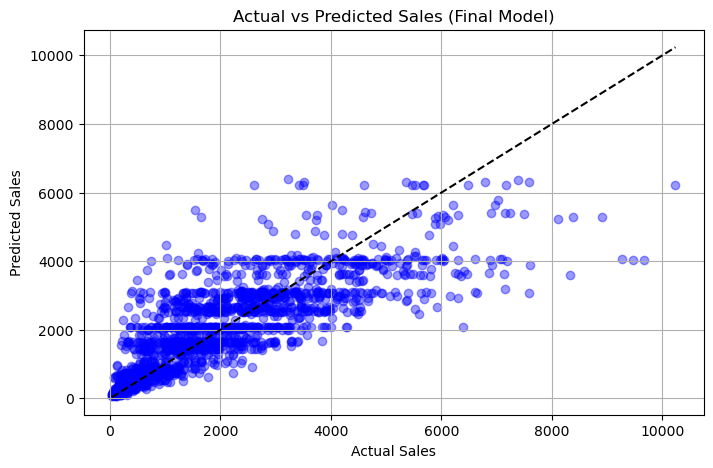

In [34]:
import matplotlib.pyplot as plt

# Plot actual vs predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='blue')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Final Model)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.grid(True)
plt.show()

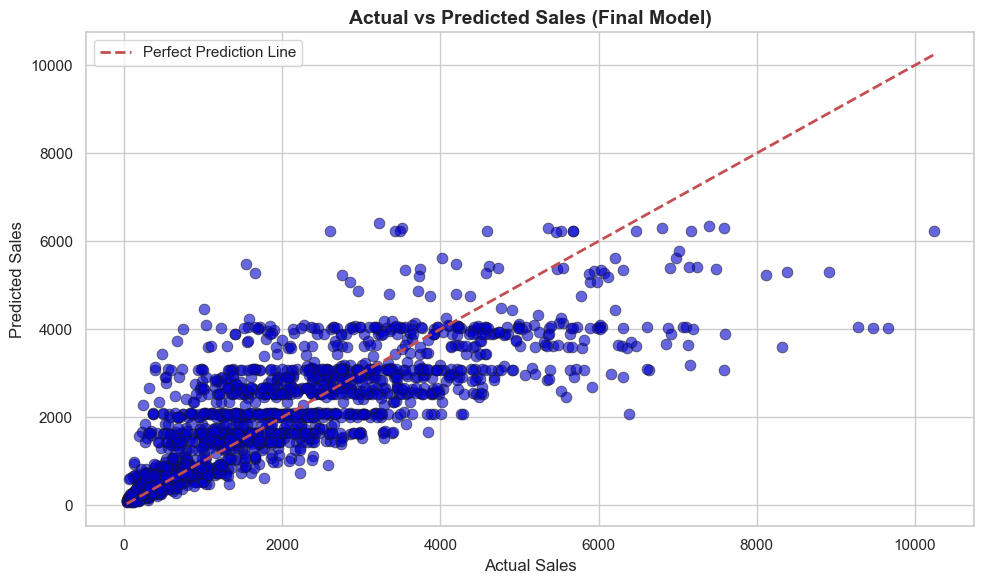

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a better visual layout
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Scatter plot
sns.scatterplot(x=y_test, y=y_pred, color='mediumblue', alpha=0.6, s=60, edgecolor='k')

# Plot a perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Perfect Prediction Line")

# Add labels and title
plt.xlabel("Actual Sales", fontsize=12)
plt.ylabel("Predicted Sales", fontsize=12)
plt.title("Actual vs Predicted Sales (Final Model)", fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

5.Analyze the Data

In [36]:
# Predict sales value using a final XGBoost model and print the prediction interval
pred = xg_final.predict(np.array([[141.6180, 9.0, 1.0, 1.0, 24]]))[0]
print(f"Sales Value is between {pred - 714.42:.2f} and {pred + 714.42:.2f}")

Sales Value is between 1361.90 and 2790.74


In [37]:
# Predict for a custom new sample (example values)
sample_input = np.array([[141.6180, 9.0, 1.0, 1.0, 24]])  # sample based on selected features
sample_prediction = xg_final.predict(sample_input)[0]

# Display prediction with a ±714.42 range (based on average std deviation)
print(f"Predicted Sales Value: {sample_prediction:.2f}")
print(f"Sales Value Range: {sample_prediction - 714.42:.2f} to {sample_prediction + 714.42:.2f}")

Predicted Sales Value: 2076.32
Sales Value Range: 1361.90 to 2790.74


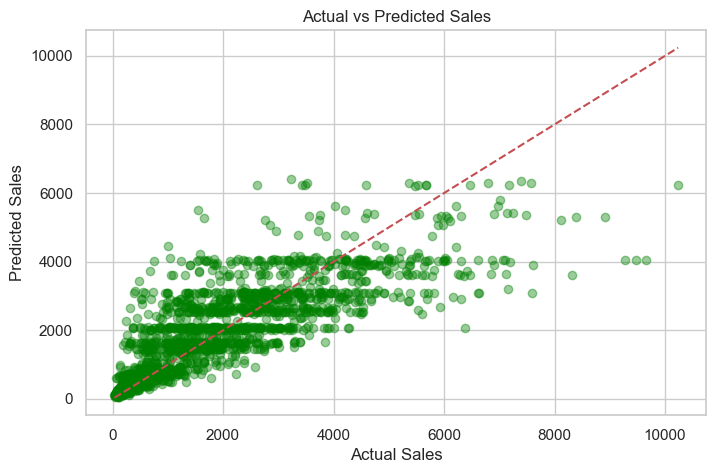

In [39]:
# Scatter plot for actual vs predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.4, color='green')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.grid(True)
plt.show()

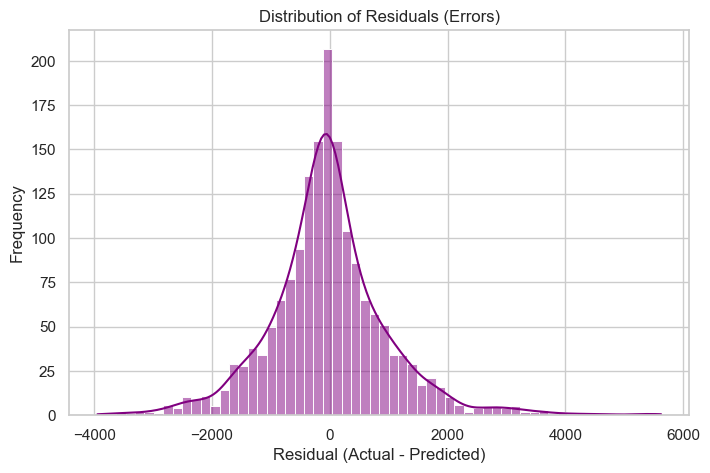

In [40]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Residuals (Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

6.Sales Forecasting

In [41]:
# Save the trained XGBoost model using joblib
import os
import joblib
os.makedirs("model", exist_ok=True)
joblib.dump(xg_final, "model/bigmart_model.pkl")

['model/bigmart_model.pkl']

In [42]:
# Export and save the trained final XGBoost model to a pickle file
import joblib
joblib.dump(xg_final, "bigmart_model.pkl")

['bigmart_model.pkl']

In [43]:
# Get and print the current working directory path
import os
print(os.getcwd())

C:\Users\acer\OneDrive - AHEAD - Amrita Vishwa Vidyapeetham\Desktop\sales forecasting files


In [44]:
# Save the final trained XGBoost model to the model directory using joblib
import joblib
joblib.dump(xg_final, 'model/bigmart_model.pkl')

['model/bigmart_model.pkl']

In [45]:
# Load model and forecast
model = joblib.load('model/bigmart_model.pkl')
new_pred = model.predict(np.array([[141.6180, 9.0, 1.0, 1.0, 24]]))[0]
print("Forecasted Sales Value:", new_pred)

Forecasted Sales Value: 2076.3245


In [46]:
# Load the test dataset
test_data = pd.read_csv("datasets/test.csv")
test_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [47]:
# Interpolate Item_Weight
test_data['Item_Weight'] = test_data['Item_Weight'].interpolate(method="linear")

In [48]:
# Handle 0s in Item_Visibility
test_data['Item_Visibility'] = test_data['Item_Visibility'].replace(0, np.nan)
test_data['Item_Visibility_interpolate'] = test_data['Item_Visibility'].interpolate(method='linear')
test_data.drop('Item_Visibility', axis=1, inplace=True)

In [49]:
# Standardize Fat Content
test_data.replace({'Item_Fat_Content': {'Low Fat': 'LF', 'low fat': 'LF', 'reg': 'Regular'}}, inplace=True)

In [50]:
# Simplify Item_Identifier
test_data['Item_Identifier'] = test_data['Item_Identifier'].apply(lambda x: x[:2])

In [51]:
# Create Outlet Age
current_year = 2025
test_data['Outlet_age'] = current_year - test_data['Outlet_Establishment_Year']
test_data.drop('Outlet_Establishment_Year', axis=1, inplace=True)

In [52]:
# Handle missing Outlet_Size
mode_outlet_test = test_data.pivot_table(values='Item_MRP', columns='Outlet_Type', aggfunc='mean')
test_data['Outlet_Size'].fillna("Medium", inplace=True)  # fallback to most frequent

In [53]:
# Ordinal Encode test set like training
from sklearn.preprocessing import OrdinalEncoder
test_encoded = test_data.copy()
for col in test_encoded.select_dtypes(include='object').columns:
    oe = OrdinalEncoder()
    test_encoded[col] = oe.fit_transform(test_encoded[[col]])

In [54]:
# Define the list of columns to drop
important_cols = ['Item_Visibility_interpolate', 'Item_Weight_interploate', 'Item_Type',
                  'Outlet_Location_Type', 'Item_Identifier', 'Item_Fat_Content']

# Drop columns only if they are present
cols_to_drop = [col for col in important_cols if col in test_encoded.columns]
test_final = test_encoded.drop(columns=cols_to_drop)


In [55]:
# Align test features with training features (X_final)
test_final = test_encoded[X_final.columns]

In [56]:
# Predict using trained model
predicted_sales = xg_final.predict(test_final)

In [57]:
# Add prediction to submission format
# Create submission DataFrame
submission = pd.DataFrame({
    "Item_Identifier": test_data['Item_Identifier'],
    "Outlet_Identifier": test_data['Outlet_Identifier'],
    "Item_Outlet_Sales": predicted_sales
})

In [58]:
# Save submission file
submission.to_csv("datasets/submission.csv", index=False)
print("Submission file 'submission.csv' generated successfully.")

Submission file 'submission.csv' generated successfully.


7.Inventory Optimization

In [59]:
import numpy as np

# Inventory Parameters (Assumptions)
LEAD_TIME = 7                 # days
ORDERING_COST = 500           # Rs per order
HOLDING_COST = 15             # Rs per unit/year
SERVICE_LEVEL = 1.65          # 95% Service Level

# Create Inventory DataFrame
inventory = submission.copy()
inventory.rename(
    columns={
        "Item_Outlet_Sales":"Predicted_Weekly_Demand"
    },
    inplace=True
)

In [60]:
# Convert weekly demand into annual demand
inventory["Annual_Demand"] = (
    inventory["Predicted_Weekly_Demand"] * 52
).round(2)

In [61]:
inventory["Daily_Demand"] = (
    inventory["Annual_Demand"] / 365
).round(2)

In [62]:
# Calculate the standard deviation of demand as 20% of the predicted weekly demand
inventory["Demand_STD"] = (
    inventory["Predicted_Weekly_Demand"] * 0.20
).round(2)

In [63]:
# Calculate safety stock using service level, demand standard deviation and the square root of lead time
inventory["Safety_Stock"] = (
    SERVICE_LEVEL *
    inventory["Demand_STD"] *
    np.sqrt(LEAD_TIME)
).round(2)

In [64]:
# Calculate the Economic Order Quantity (EOQ) using the Wilson Formula and round to two decimal places
inventory["EOQ"] = (
    np.sqrt(
        (2 *
         inventory["Annual_Demand"] *
         ORDERING_COST)
        /
        HOLDING_COST
    )
).round(2)

In [65]:
# Calculate the reorder point based on lead time demand plus safety stock, rounded to two decimal places
inventory["Reorder_Point"] = (
    inventory["Daily_Demand"] *
    LEAD_TIME +
    inventory["Safety_Stock"]
).round(2)

In [66]:
# Segment inventory stock levels based on predicted weekly demand thresholds using a custom function
def inventory_status(demand):
    if demand >= 3000:
        return "High Stock Required"
    elif demand >= 1500:
        return "Medium Stock Required"
    else:
        return "Low Stock Required"

inventory["Inventory_Status"] = inventory[
    "Predicted_Weekly_Demand"
].apply(inventory_status)

In [67]:
# Filter and reorder the inventory DataFrame columns to key metrics and display the first 10 rows
inventory = inventory[[
    "Item_Identifier",
    "Outlet_Identifier",
    "Predicted_Weekly_Demand",
    "EOQ",
    "Safety_Stock",
    "Reorder_Point",
    "Inventory_Status"
]]
inventory.head(10)

,Item_Identifier,Outlet_Identifier,Predicted_Weekly_Demand,EOQ,Safety_Stock,Reorder_Point,Inventory_Status
0,FD,OUT049,1640.497559,2384.760010,1432.319946,3068.290039,Medium Stock Required
1,FD,OUT017,1444.323730,2237.629883,1261.020020,2701.409912,Low Stock Required
2,NC,OUT010,586.110840,1425.430054,511.720001,1096.219971,Low Stock Required
3,FD,OUT017,2539.586670,2967.139893,2217.320068,4749.919922,Medium Stock Required
4,FD,OUT027,5949.374023,4541.419922,5194.370117,11127.429688,High Stock Required
5,FD,OUT046,2003.180542,2635.219971,1748.989990,3746.649902,Medium Stock Required
6,FD,OUT018,709.745850,1568.579956,619.679993,1327.449951,Low Stock Required
7,FD,OUT027,2184.972168,2752.189941,1907.680054,4086.639893,Medium Stock Required
8,FD,OUT045,1517.731445,2293.790039,1325.140015,2838.679932,Medium Stock Required
9,FD,OUT017,3055.663574,3254.679932,2667.879883,5715.189941,High Stock Required


In [68]:
# Export the optimized inventory metrics to a CSV file
inventory.to_csv(
    "datasets/inventory_optimization.csv",
    index=False
)
print("Inventory Optimization File Saved Successfully.")

Inventory Optimization File Saved Successfully.


In [69]:
# Export the final trained XGBoost model to a pickle file using joblib and confirm successful saving
import joblib
joblib.dump(
    xg_final,
    "model/bigmart_model.pkl"
)
print("Model Saved Successfully.")

Model Saved Successfully.
